# ITCZ DJF berbasis curah hujan maksimum v5 - GPCP

Notebook ini mempertahankan kerangka DJF yang sama, tetapi memakai data GPCP monthly precipitation sebagai sumber curah hujan dan tetap hanya menggunakan smoothing Gaussian anisotropik sebelum pencarian maksimum ITCZ. Tidak ada pelacakan kontinuitas lintas bujur pada versi ini.

Output yang dibuat:
- Peta raw blind-argmax berbasis Gaussian smoothing
- Peta zoom Maritim Kontinen
- Peta climatology untuk cek konsistensi hasil


In [20]:
from data_processing.config import NINO34_PATH

from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from scipy.ndimage import gaussian_filter

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from IPython.display import display

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Helvetica'

FIGURE_DIR = Path('.')
ITCZ_SMOOTH_SIGMA_LAT = 0
ITCZ_SMOOTH_SIGMA_LON = 0
ITCZ_LAT_MIN = -20.0
ITCZ_LAT_MAX = 20.0
RAINFALL_PATH = Path('/Users/rizzie/ClimateData/noaa-monthly/precip-mon-gpcp-1979-2025.nc')
NINO34_PATH = Path(nino34_path = NINO34_PATH)
NINO34_COLUMN = '   Nino Anom 3.4 Index  using ersstv5 from CPC  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/'

START_YEAR = 1981
END_YEAR = 2020
ALL_YEARS = np.arange(START_YEAR, END_YEAR + 1)
P1_YEARS = np.arange(1981, 2007)
P2_YEARS = np.arange(2007, 2021)
PERIOD_ORDER = ['All', 'P1', 'P2']
PHASE_ORDER = ['Climatology', 'El Niño', 'La Niña', 'Neutral']

PHASE_COLORS = {
    'Climatology': 'black',
    'El Niño': 'red',
    'La Niña': 'blue',
    'Neutral': 'green',
}
PERIOD_STYLES = {
    'All': '-',
    'P1': '--',
    'P2': ':',
}
PHASE_LABELS = {
    'Climatology': 'Klimatologi',
    'El Niño': 'El Niño',
    'La Niña': 'La Niña',
    'Neutral': 'Netral',
}
PERIOD_LABELS = {
    'All': 'Seluruh periode',
    'P1': 'P1 (1981-2006)',
    'P2': 'P2 (2007-2020)',
}

# Keep the legacy name for the existing Gaussian smoothing parameter.
GAUSSIAN_SIGMA = ITCZ_SMOOTH_SIGMA_LAT


In [21]:
FIGURE_DIR = Path('.')
ITCZ_SMOOTH_SIGMA_LAT = 2.0
ITCZ_SMOOTH_SIGMA_LON = 8
ITCZ_LAT_MIN = -20.0
ITCZ_LAT_MAX = 20.0
RAINFALL_PATH = Path('/Users/rizzie/ClimateData/noaa-monthly/precip-mon-gpcp-1979-2025.nc')
NINO34_PATH = Path(nino34_path = NINO34_PATH)
NINO34_COLUMN = '   Nino Anom 3.4 Index  using ersstv5 from CPC  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/'

START_YEAR = 1981
END_YEAR = 2020
ALL_YEARS = np.arange(START_YEAR, END_YEAR + 1)
P1_YEARS = np.arange(1981, 2007)
P2_YEARS = np.arange(2007, 2021)
PERIOD_ORDER = ['All', 'P1', 'P2']
PHASE_ORDER = ['Climatology', 'El Niño', 'La Niña', 'Neutral']

PHASE_COLORS = {
    'Climatology': 'black',
    'El Niño': 'red',
    'La Niña': 'blue',
    'Neutral': 'green',
}
PERIOD_STYLES = {
    'All': '-',
    'P1': '--',
    'P2': ':',
}
PHASE_LABELS = {
    'Climatology': 'Klimatologi',
    'El Niño': 'El Niño',
    'La Niña': 'La Niña',
    'Neutral': 'Netral',
}
PERIOD_LABELS = {
    'All': 'Seluruh periode',
    'P1': 'P1 (1981-2006)',
    'P2': 'P2 (2007-2020)',
}

# Keep the legacy name for the existing Gaussian smoothing parameter.
GAUSSIAN_SIGMA = ITCZ_SMOOTH_SIGMA_LAT


# Load rainfall and Niño3.4 series
rain_ds = xr.open_dataset(RAINFALL_PATH)
if 'tp' in rain_ds.data_vars:
    rain = rain_ds['tp']
elif 'precip' in rain_ds.data_vars:
    rain = rain_ds['precip']
elif 'precipitation' in rain_ds.data_vars:
    rain = rain_ds['precipitation']
else:
    rain = rain_ds[list(rain_ds.data_vars)[0]]

rename_map = {}
if 'valid_time' in rain.dims or 'valid_time' in rain.coords:
    rename_map['valid_time'] = 'time'
if 'latitude' in rain.dims or 'latitude' in rain.coords:
    rename_map['latitude'] = 'lat'
if 'longitude' in rain.dims or 'longitude' in rain.coords:
    rename_map['longitude'] = 'lon'
if rename_map:
    rain = rain.rename(rename_map)

rain = rain.sel(time=slice(f'{START_YEAR - 1}-12-01', f'{END_YEAR}-02-29'))
rain = rain.assign_coords(lon=(rain.lon % 360)).sortby('lon')
rain = rain.rename('precipitation')
rain.attrs['units'] = 'mm month-1'
rain = rain.chunk({'time': 12, 'lat': 181, 'lon': 360})

nino34 = pd.read_csv(
    NINO34_PATH,
    usecols=['Date', NINO34_COLUMN],
    parse_dates=['Date'],
)
nino34 = nino34.set_index('Date').loc[f'{START_YEAR - 1}-12-01':f'{END_YEAR}-02-29'].copy()
nino34[NINO34_COLUMN] = pd.to_numeric(nino34[NINO34_COLUMN], errors='coerce').replace([-9999.0, -99.99], np.nan)


In [22]:
# Load rainfall and Niño3.4 series
rain_ds = xr.open_dataset(RAINFALL_PATH)
if 'precip' in rain_ds.data_vars:
    rain = rain_ds['precip']
elif 'tp' in rain_ds.data_vars:
    rain = rain_ds['tp']
elif 'precipitation' in rain_ds.data_vars:
    rain = rain_ds['precipitation']
else:
    rain = rain_ds[list(rain_ds.data_vars)[0]]

rename_map = {}
if 'valid_time' in rain.dims or 'valid_time' in rain.coords:
    rename_map['valid_time'] = 'time'
if 'latitude' in rain.dims or 'latitude' in rain.coords:
    rename_map['latitude'] = 'lat'
if 'longitude' in rain.dims or 'longitude' in rain.coords:
    rename_map['longitude'] = 'lon'
if rename_map:
    rain = rain.rename(rename_map)

rain = rain.sel(time=slice(f'{START_YEAR - 1}-12-01', f'{END_YEAR}-02-29'))
rain = rain.assign_coords(lon=(rain.lon % 360)).sortby('lon')
rain = rain.rename('precipitation')
rain.attrs['units'] = 'mm month-1'
rain = rain.chunk({'time': 12, 'lat': 181, 'lon': 360})

nino34 = pd.read_csv(
    NINO34_PATH,
    usecols=['Date', NINO34_COLUMN],
    parse_dates=['Date'],
)
nino34 = nino34.set_index('Date').loc[f'{START_YEAR - 1}-12-01':f'{END_YEAR}-02-29'].copy()
nino34[NINO34_COLUMN] = pd.to_numeric(nino34[NINO34_COLUMN], errors='coerce').replace([-9999.0, -99.99], np.nan)


In [23]:
def normalize_longitude(da: xr.DataArray) -> xr.DataArray:
    lon = np.asarray(da['lon'].values)
    lon_norm = np.mod(lon, 360.0)
    return da.assign_coords(lon=lon_norm).sortby('lon')


def make_djf_means(da: xr.DataArray, start_year: int = START_YEAR, end_year: int = END_YEAR) -> xr.DataArray:
    djf = da.sel(time=da.time.dt.month.isin([12, 1, 2])).copy()
    time_index = pd.DatetimeIndex(djf['time'].values)
    djf_year_values = np.where(time_index.month == 12, time_index.year + 1, time_index.year).astype(int)
    djf = djf.assign_coords(djf_year=('time', djf_year_values))
    season_counts = pd.Series(djf_year_values).value_counts().sort_index()
    complete_years = season_counts[season_counts == 3].index.to_numpy(dtype=int)
    complete_years = complete_years[(complete_years >= start_year) & (complete_years <= end_year)]
    if complete_years.size == 0:
        raise ValueError('Tidak ada musim DJF lengkap untuk curah hujan.')
    return djf.groupby('djf_year').mean('time').sel(djf_year=complete_years)


def make_djf_nino34_mean(df: pd.DataFrame, column: str, start_year: int = START_YEAR, end_year: int = END_YEAR) -> pd.Series:
    subset = df.loc[f'{start_year - 1}-12-01':f'{end_year}-02-29', [column]].copy()
    subset = subset[subset.index.month.isin([12, 1, 2])].copy()
    subset['djf_year'] = subset.index.year + (subset.index.month == 12).astype('int8')
    valid_counts = subset.groupby('djf_year')[column].apply(lambda s: s.notna().sum())
    complete_years = valid_counts[valid_counts == 3].index.to_numpy(dtype=int)
    complete_years = complete_years[(complete_years >= start_year) & (complete_years <= end_year)]
    if complete_years.size == 0:
        raise ValueError('Tidak ada musim DJF lengkap untuk Niño3.4.')
    return subset.groupby('djf_year')[column].mean().loc[complete_years]


def classify_enso_from_djf_nino34(value: float) -> str:
    if pd.isna(value):
        return np.nan
    if value >= 0.5:
        return 'El Niño'
    if value <= -0.5:
        return 'La Niña'
    return 'Neutral'


def build_event_table(nino_series: pd.Series, years, period_group: str) -> pd.DataFrame:
    years = np.asarray(years, dtype=int)
    table = pd.DataFrame({
        'djf_year': years,
        'nino34_djf_mean': nino_series.reindex(years).to_numpy(),
    })
    table['enso_phase'] = table['nino34_djf_mean'].map(classify_enso_from_djf_nino34)
    table['period_group'] = period_group
    return table


def composite_rainfall(rain_djf: xr.DataArray, years) -> xr.DataArray:
    years = np.asarray(years, dtype=int)
    template = normalize_longitude(rain_djf.isel(djf_year=0, drop=True)).transpose('lat', 'lon')
    if years.size == 0:
        return xr.full_like(template, np.nan)
    composite = rain_djf.sel(djf_year=years).mean('djf_year')
    return normalize_longitude(composite).transpose('lat', 'lon')


def gaussian_smooth_anisotropic(rain_2d: xr.DataArray, sigma_lat: float = ITCZ_SMOOTH_SIGMA_LAT, sigma_lon: float = ITCZ_SMOOTH_SIGMA_LON) -> xr.DataArray:
    rain_2d = rain_2d.transpose('lat', 'lon')
    values = np.asarray(rain_2d.values, dtype=float)
    valid = np.isfinite(values)
    filled = np.where(valid, values, 0.0)
    smoothed = gaussian_filter(filled, sigma=(sigma_lat, sigma_lon), mode='nearest')
    weights = gaussian_filter(valid.astype(float), sigma=(sigma_lat, sigma_lon), mode='nearest')
    with np.errstate(invalid='ignore', divide='ignore'):
        smoothed = np.where(weights > 0, smoothed / weights, np.nan)
    return xr.DataArray(smoothed, coords=rain_2d.coords, dims=rain_2d.dims, name=rain_2d.name)


def gaussian_smooth_2d(rain_2d: xr.DataArray, sigma: float = GAUSSIAN_SIGMA) -> xr.DataArray:
    return gaussian_smooth_anisotropic(rain_2d, sigma_lat=sigma, sigma_lon=max(ITCZ_SMOOTH_SIGMA_LON, sigma))


def extract_itcz_max_precip(
    rain_2d: xr.DataArray,
    lat_min: float = ITCZ_LAT_MIN,
    lat_max: float = ITCZ_LAT_MAX,
    sigma_lat: float = ITCZ_SMOOTH_SIGMA_LAT,
    sigma_lon: float = ITCZ_SMOOTH_SIGMA_LON,
) -> xr.DataArray:
    rain_2d = normalize_longitude(rain_2d).transpose('lat', 'lon')
    rain_2d = gaussian_smooth_anisotropic(rain_2d, sigma_lat=sigma_lat, sigma_lon=sigma_lon)
    band = rain_2d.where((rain_2d['lat'] >= lat_min) & (rain_2d['lat'] <= lat_max), drop=True).sortby('lat')
    if band.sizes.get('lat', 0) == 0 or band.sizes.get('lon', 0) == 0:
        return xr.DataArray(
            np.full(rain_2d.sizes['lon'], np.nan, dtype=float),
            coords={'lon': rain_2d['lon'].values},
            dims='lon',
            name='itcz_latitude',
        )
    values = np.asarray(band.values, dtype=float)
    lats = np.asarray(band['lat'].values, dtype=float)
    lons = np.asarray(band['lon'].values, dtype=float)
    line = np.full(lons.shape, np.nan, dtype=float)
    for j in range(values.shape[1]):
        column = values[:, j]
        if not np.isfinite(column).any():
            continue
        idx = int(np.nanargmax(column))
        if np.isfinite(column[idx]):
            line[j] = float(lats[idx])
    return xr.DataArray(line, coords={'lon': lons}, dims='lon', name='itcz_latitude')


def plot_itcz_map(itcz_lines_by_period, title: str, extent, xticks, yticks, save_path: Path, figsize=(13.5, 6.5)) -> None:
    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(right=0.78)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=0.7, color='black', zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.35, color='0.6', alpha=0.4, linestyle='--')
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(direction='out', top=True, right=True, labelsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title, fontsize=15, fontweight='bold', loc='left', pad=10)

    for period in PERIOD_ORDER:
        period_lines = itcz_lines_by_period.get(period, {})
        for phase in PHASE_ORDER:
            if phase not in period_lines:
                continue
            line = period_lines[phase]
            ax.plot(
                line['lon'].values,
                line.values,
                color=PHASE_COLORS[phase],
                linestyle=PERIOD_STYLES[period],
                linewidth=2.0,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

    color_handles = [
        Line2D([0], [0], color=PHASE_COLORS['Climatology'], lw=2.5, label=PHASE_LABELS['Climatology']),
        Line2D([0], [0], color=PHASE_COLORS['El Niño'], lw=2.5, label=PHASE_LABELS['El Niño']),
        Line2D([0], [0], color=PHASE_COLORS['La Niña'], lw=2.5, label=PHASE_LABELS['La Niña']),
        Line2D([0], [0], color=PHASE_COLORS['Neutral'], lw=2.5, label=PHASE_LABELS['Neutral']),
    ]
    style_handles = [
        Line2D([0], [0], color='black', lw=2.5, linestyle=PERIOD_STYLES['All'], label=PERIOD_LABELS['All']),
        Line2D([0], [0], color='black', lw=2.5, linestyle=PERIOD_STYLES['P1'], label=PERIOD_LABELS['P1']),
        Line2D([0], [0], color='black', lw=2.5, linestyle=PERIOD_STYLES['P2'], label=PERIOD_LABELS['P2']),
    ]
    color_legend = ax.legend(handles=color_handles, loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, framealpha=0.95, title='Warna')
    ax.add_artist(color_legend)
    ax.legend(handles=style_handles, loc='lower left', bbox_to_anchor=(1.01, 0.42), frameon=True, framealpha=0.95, title='Pola garis')

    fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.15)
    print(f'Saved figure: {save_path}')
    plt.show()
    plt.close(fig)


## Klasifikasi ENSO dan tabel tahun

Tabel ini dipakai untuk membangun komposit DJF per periode dan fase ENSO.

In [24]:
rain_djf_mean = make_djf_means(rain).transpose('djf_year', 'lat', 'lon')
nino34_djf_mean = make_djf_nino34_mean(nino34, NINO34_COLUMN)

common_years = np.intersect1d(
    rain_djf_mean['djf_year'].values.astype(int),
    nino34_djf_mean.index.to_numpy(dtype=int),
)
rain_djf_mean = rain_djf_mean.sel(djf_year=common_years)
nino34_djf_mean = nino34_djf_mean.reindex(common_years)

events_long = pd.concat(
    [
        build_event_table(nino34_djf_mean, ALL_YEARS, 'All'),
        build_event_table(nino34_djf_mean, P1_YEARS, 'P1'),
        build_event_table(nino34_djf_mean, P2_YEARS, 'P2'),
    ],
    ignore_index=True,
)
events_long['period_group'] = pd.Categorical(events_long['period_group'], categories=PERIOD_ORDER, ordered=True)
events_long = events_long.sort_values(['period_group', 'djf_year']).reset_index(drop=True)

event_counts = (
    events_long.groupby(['period_group', 'enso_phase'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=PERIOD_ORDER, columns=['El Niño', 'La Niña', 'Neutral'])
)

print('Jumlah tahun ENSO DJF per periode:')
print(event_counts.to_string())

for period in PERIOD_ORDER:
    period_table = events_long[events_long['period_group'] == period]
    print(f'\nDaftar tahun {period}:')
    for phase in ['El Niño', 'La Niña', 'Neutral']:
        years = period_table.loc[period_table['enso_phase'] == phase, 'djf_year'].tolist()
        print(f'  {phase}: {years}')

display(events_long)


Jumlah tahun ENSO DJF per periode:
enso_phase    El Niño  La Niña  Neutral
period_group                           
All                13       15       12
P1                  8       10        8
P2                  5        5        4

Daftar tahun All:
  El Niño: [1983, 1987, 1988, 1992, 1995, 1998, 2003, 2005, 2007, 2010, 2015, 2016, 2019]
  La Niña: [1984, 1985, 1986, 1989, 1996, 1997, 1999, 2000, 2001, 2006, 2008, 2009, 2011, 2012, 2018]
  Neutral: [1981, 1982, 1990, 1991, 1993, 1994, 2002, 2004, 2013, 2014, 2017, 2020]

Daftar tahun P1:
  El Niño: [1983, 1987, 1988, 1992, 1995, 1998, 2003, 2005]
  La Niña: [1984, 1985, 1986, 1989, 1996, 1997, 1999, 2000, 2001, 2006]
  Neutral: [1981, 1982, 1990, 1991, 1993, 1994, 2002, 2004]

Daftar tahun P2:
  El Niño: [2007, 2010, 2015, 2016, 2019]
  La Niña: [2008, 2009, 2011, 2012, 2018]
  Neutral: [2013, 2014, 2017, 2020]


,djf_year,nino34_djf_mean,enso_phase,period_group
0,1981,-0.316667,Neutral,All
1,1982,-0.080000,Neutral,All
2,1983,2.163333,El Niño,All
3,1984,-0.630000,La Niña,All
4,1985,-1.073333,La Niña,All
...,...,...,...,...
75,2016,2.496667,El Niño,P2
76,2017,-0.336667,Neutral,P2
77,2018,-0.913333,La Niña,P2
78,2019,0.750000,El Niño,P2


## Komposit DJF dan ekstraksi ITCZ

Setiap komposit dihitung dari DJF mean rainfall. ITCZ diambil sebagai latitude curah hujan maksimum per longitude setelah smoothing Gaussian anisotropik.

In [25]:
phase_years_map = {}
for period in PERIOD_ORDER:
    period_table = events_long[events_long['period_group'] == period]
    phase_years_map[period] = {
        'Climatology': period_table['djf_year'].to_numpy(),
        'El Niño': period_table.loc[period_table['enso_phase'] == 'El Niño', 'djf_year'].to_numpy(),
        'La Niña': period_table.loc[period_table['enso_phase'] == 'La Niña', 'djf_year'].to_numpy(),
        'Neutral': period_table.loc[period_table['enso_phase'] == 'Neutral', 'djf_year'].to_numpy(),
    }

rain_composites = {}
itcz_lines = {}
for period in PERIOD_ORDER:
    rain_composites[period] = {}
    itcz_lines[period] = {}
    for phase in PHASE_ORDER:
        composite = composite_rainfall(rain_djf_mean, phase_years_map[period][phase])
        rain_composites[period][phase] = composite
        itcz_lines[period][phase] = extract_itcz_max_precip(composite)

for period in PERIOD_ORDER:
    for phase in PHASE_ORDER:
        line = itcz_lines[period][phase]
        valid = int(line.count())
        print(f'{period:>3s} | {phase:<11s} | lon valid = {valid:4d}')


All | Climatology | lon valid =  144
All | El Niño     | lon valid =  144
All | La Niña     | lon valid =  144
All | Neutral     | lon valid =  144
 P1 | Climatology | lon valid =  144
 P1 | El Niño     | lon valid =  144
 P1 | La Niña     | lon valid =  144
 P1 | Neutral     | lon valid =  144
 P2 | Climatology | lon valid =  144
 P2 | El Niño     | lon valid =  144
 P2 | La Niña     | lon valid =  144
 P2 | Neutral     | lon valid =  144


## Peta 1 - Global

Peta global dipakai sebagai cek cepat untuk hasil Gaussian-smoothed max-precip.

Saved figure: djf_itcz_global_maxprecip_all_p1_p2_v5.png


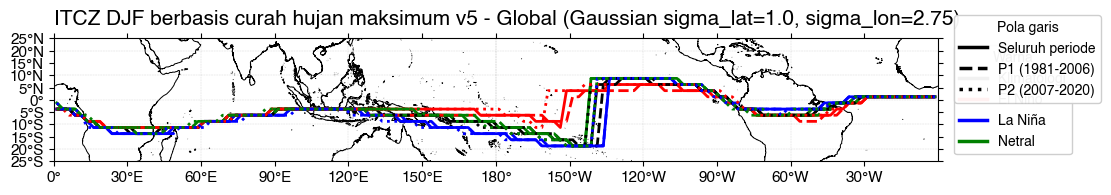

In [26]:
global_extent = [0, 360, -25, 25]
global_lon_ticks = np.arange(0, 360, 30)
global_lat_ticks = np.arange(-25, 26, 5)

plot_itcz_map(
    itcz_lines,
    title='ITCZ DJF berbasis curah hujan maksimum v5 - Global (Gaussian sigma_lat=1.0, sigma_lon=2.75)',
    extent=global_extent,
    xticks=global_lon_ticks,
    yticks=global_lat_ticks,
    save_path=FIGURE_DIR / 'djf_itcz_global_maxprecip_all_p1_p2_v5.png',
    figsize=(13.5, 6.5),
)


## Peta 2 - Maritim Kontinen

Zoom Maritim Kontinen adalah fokus utama untuk melihat apakah smoothing Gaussian saja sudah cukup mengurangi loncatan semu.

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


Saved figure: djf_itcz_mc_90E_155E_maxprecip_all_p1_p2_v5.png


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


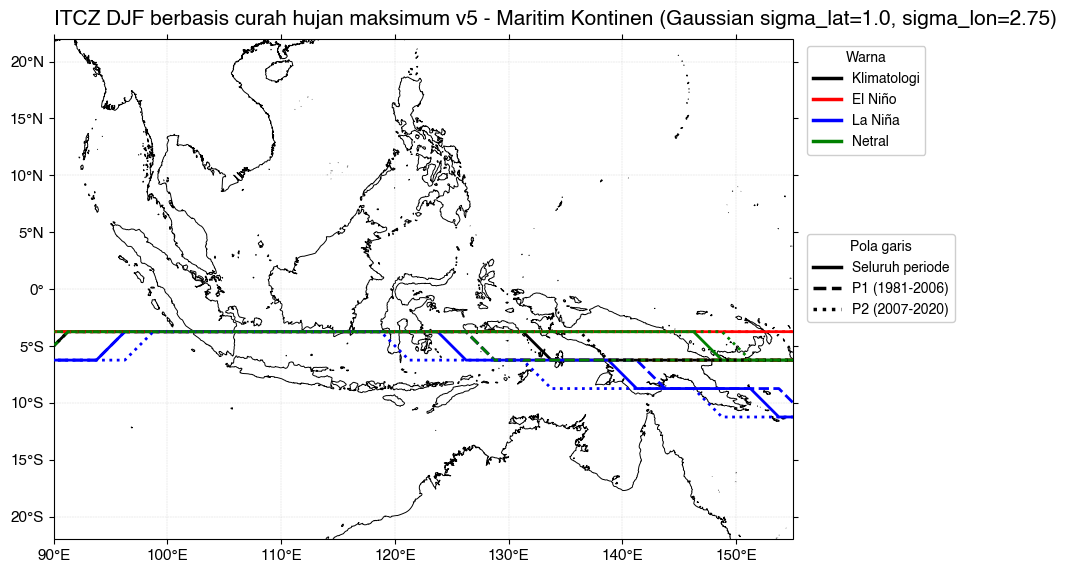

In [27]:
mc_extent = [90, 155, -22, 22]
mc_lon_ticks = np.arange(90, 156, 10)
mc_lat_ticks = np.arange(-20, 21, 5)

plot_itcz_map(
    itcz_lines,
    title='ITCZ DJF berbasis curah hujan maksimum v5 - Maritim Kontinen (Gaussian sigma_lat=1.0, sigma_lon=2.75)',
    extent=mc_extent,
    xticks=mc_lon_ticks,
    yticks=mc_lat_ticks,
    save_path=FIGURE_DIR / 'djf_itcz_mc_90E_155E_maxprecip_all_p1_p2_v5.png',
    figsize=(12.5, 6.5),
)


Saved figure: djf_itcz_global_climatology_all_period_v5.png


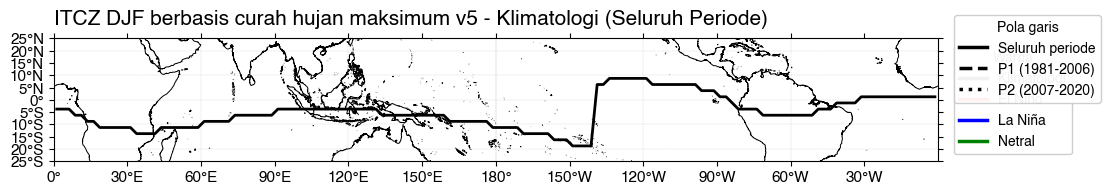

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


Saved figure: djf_itcz_mc_climatology_all_period_v5.png


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


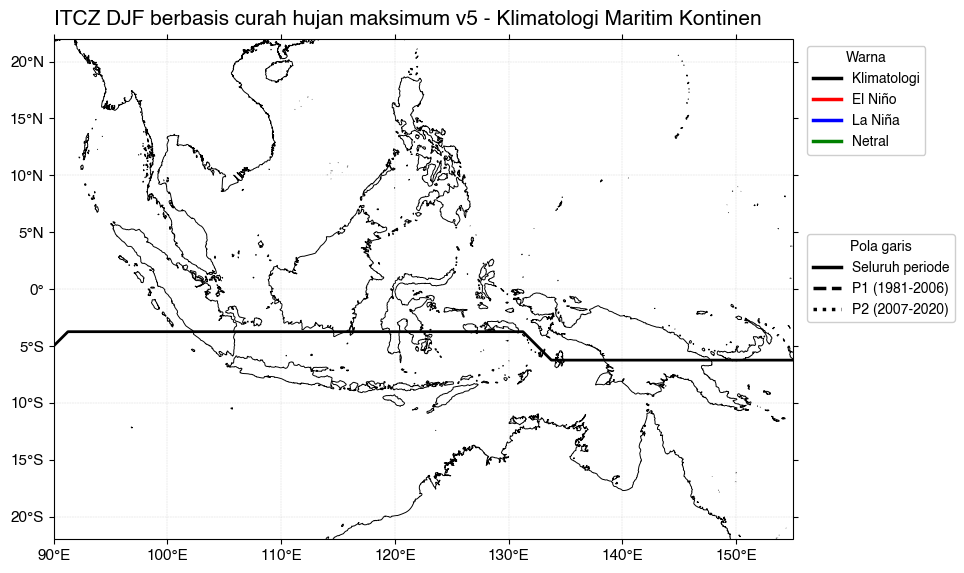

In [28]:
climatology_only = {
    'All': {
        'Climatology': itcz_lines['All']['Climatology'],
    }
}

plot_itcz_map(
    climatology_only,
    title='ITCZ DJF berbasis curah hujan maksimum v5 - Klimatologi (Seluruh Periode)',
    extent=global_extent,
    xticks=global_lon_ticks,
    yticks=global_lat_ticks,
    save_path=FIGURE_DIR / 'djf_itcz_global_climatology_all_period_v5.png',
    figsize=(13.5, 6.5),
)

plot_itcz_map(
    climatology_only,
    title='ITCZ DJF berbasis curah hujan maksimum v5 - Klimatologi Maritim Kontinen',
    extent=mc_extent,
    xticks=mc_lon_ticks,
    yticks=mc_lat_ticks,
    save_path=FIGURE_DIR / 'djf_itcz_mc_climatology_all_period_v5.png',
    figsize=(12.5, 6.5),
)


## Ringkasan

Versi ini memakai smoothing Gaussian anisotropik saja sebelum argmax latitude di sabuk 20S–20N. Tidak ada continuity tracking, jadi hasilnya lebih sederhana dan tetap langsung dibandingkan dengan versi v2/v3 bila diperlukan.